In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTAMOS LIBREARIAS PARA KMEANS

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

# GENERAMOS DATOS ALEATORIOS PARA EL EJEMPLO con MAKE_BLOBS

In [3]:
X,y,c = make_blobs(500,cluster_std=0.8,centers=4,n_features=2,return_centers=True)

In [4]:
df_blobs = pd.DataFrame(
    {
        'x1':X[:,0],
        'x2':X[:,1],
        'y':y
    }
)
df_blobs

,x1,x2,y
0,-0.151552,-1.322275,1
1,-3.749917,6.607460,0
2,-5.494454,6.520716,3
3,-3.663989,5.911748,2
4,-5.492413,7.404937,3
...,...,...,...
495,-4.051903,5.658383,0
496,-5.084678,7.504415,3
497,-1.567441,-0.461741,1
498,-1.950725,3.983353,0


In [5]:
df_centers = pd.DataFrame(
    {
        'x1':c[:,0],
        'x2':c[:,1]
    }
)
df_centers

,x1,x2
0,-2.560719,5.792662
1,-0.395403,0.132827
2,-4.143881,4.653656
3,-5.631558,7.356027


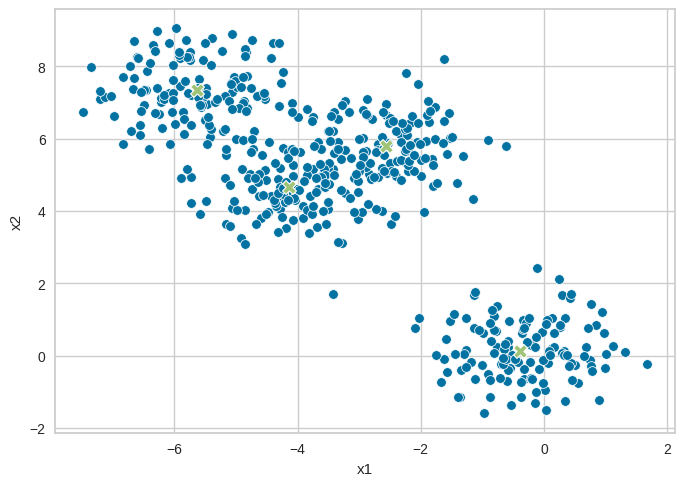

In [6]:
sns.scatterplot(data=df_blobs,x='x1',y='x2')
sns.scatterplot(data=df_centers,x='x1',y='x2',marker='X',s=100)
plt.show()

# CREAMOS UNA FUNCIÓN PARA PROBAR VARIOS NROS DE CLUSTERS

In [7]:
def vis_cluster(k):
    kmeans = KMeans(n_clusters=k)
    df_cluster = kmeans.fit_predict(X)
    df_blobs['cluster'] = df_cluster
    k_means_centers = kmeans.cluster_centers_
    df_k_means_center = pd.DataFrame(
        {
            'x1':k_means_centers[:,0],
            'x2':k_means_centers[:,1]

        }
    )
    fig = plt.figure(figsize=(9,9))
    sns.scatterplot(data=df_blobs,  x='x1', y='x2', hue= 'cluster', palette='coolwarm')
    sns.scatterplot(data=df_centers,  x='x1', y='x2', marker='X', s=150 , color='red')
    sns.scatterplot(data=df_k_means_center,  x='x1', y='x2', marker='o', s=150 , color='yellow')
    plt.show()

3


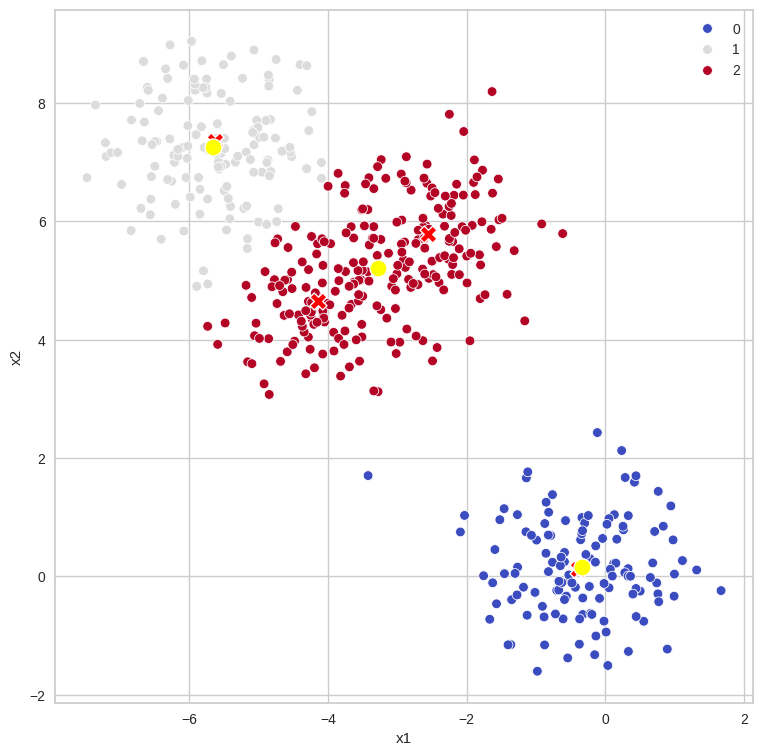

4


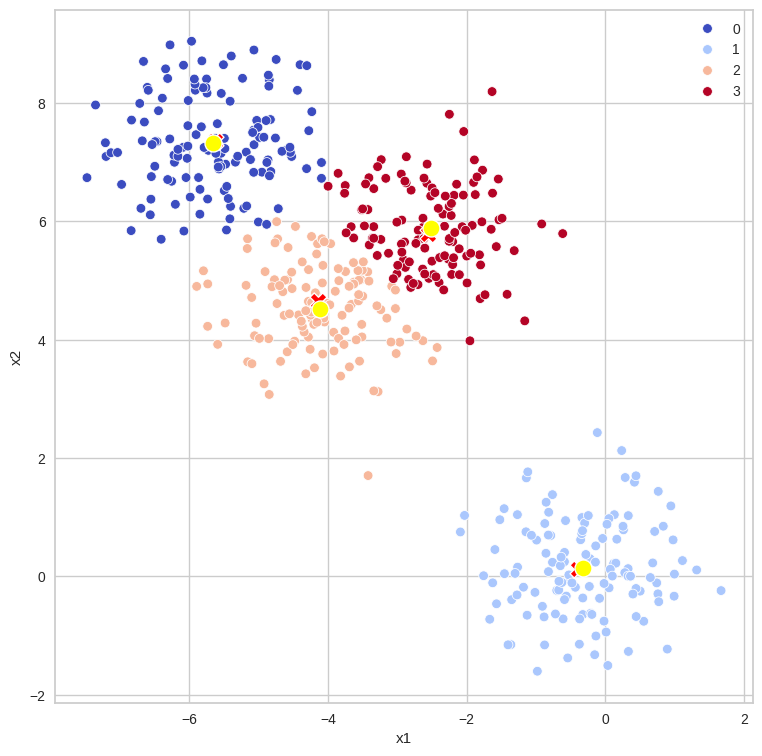

5


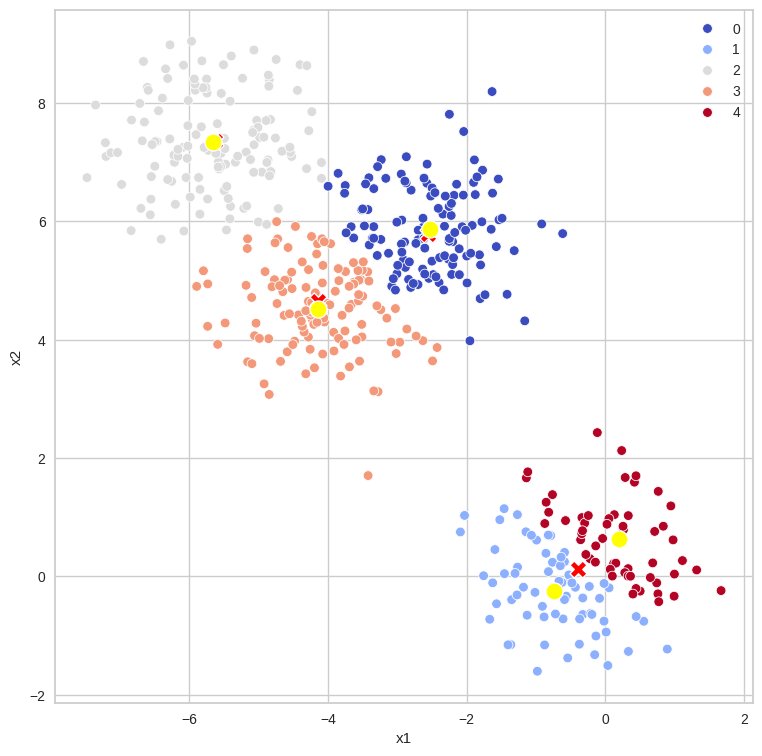

6


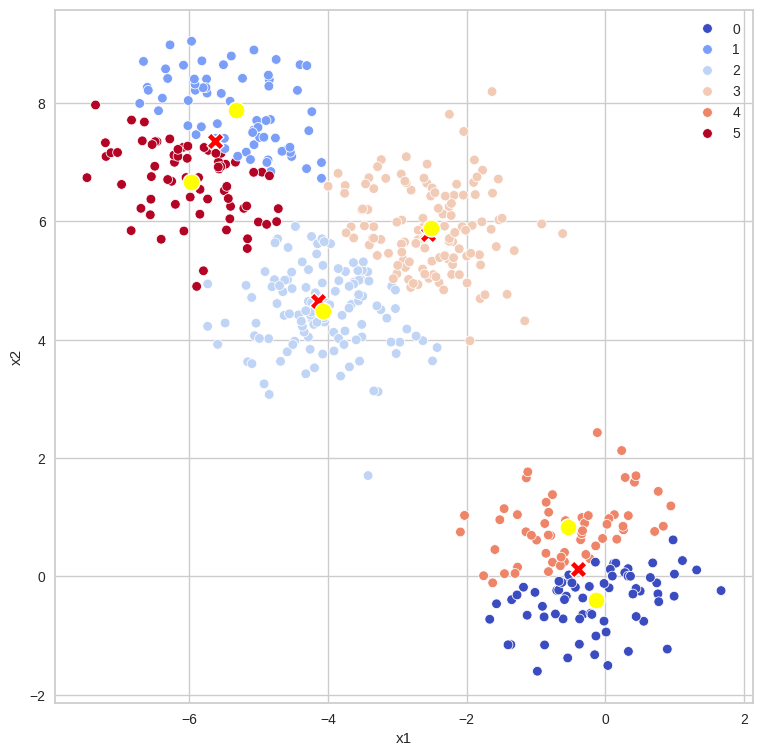

In [8]:
for _ in range(3,7):
  print(_)
  vis_cluster(_)

# Método del Codo en K-Means
Es una técnica para encontrar el número óptimo de clusters en K-Means analizando cómo disminuye la inercia.

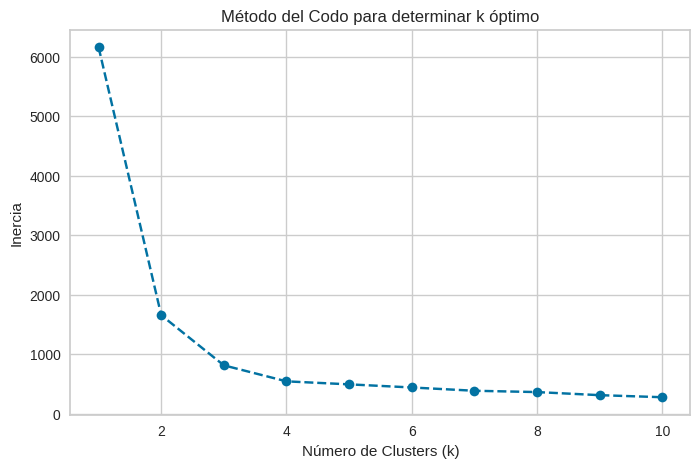

In [9]:
from sklearn.cluster import KMeans

inertia = []
k_values = range(1,11)

for k in k_values:
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para determinar k óptimo')
plt.show()